## Environment Setup


### Directory


In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))


### Standard Imports


In [2]:
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est import *
import skrom.problem_classes.static.master_class as master
import importlib
import numpy as np
import matplotlib.pyplot as plt

# register problem (runs @register_problem)
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def")


PETSc available: True


In [3]:
import sci_mplstyle_package

## Full Order Simulation (Offline)


In [4]:
generate = False  # set True to regenerate snapshots and ROM_data

if generate:
    sim = master.fom_simulation(num_snapshots=16)
    sim.run_simulation()


### Load Simulation data


In [5]:
from pathlib import Path
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

param_list = np.asarray(sim_data['param_list'])
LS = np.asarray(fos_solutions)

train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']
LS_train = LS[train_mask]
LS_test  = LS[test_mask]


[load_rom_data] loaded from D:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\tests\problem_plate_with_hole_tension_2d\ROM_data


In [6]:
mesh=sim_data['mesh'].item()

In [7]:
from skfem import Basis
from skfem.element import ElementTriP1, ElementVector

element = ElementVector(ElementTriP1())
basis_vec = Basis(mesh, element)

In [8]:
# Extract nodal displacements
u_node = LS_train[0][basis_vec.nodal_dofs]  # shape (2, n_nodes)
ux = u_node[0, :]
uy = u_node[1, :]

# Save to VTK (ParaView-readable)
mesh.save(
    "plate_with_hole_solution.vtk",
    point_data={
        "u_x": ux,
        "u_y": uy,
        "u_mag": (ux**2 + uy**2)**0.5,
    }
)


Warning: VTK requires 3D points, but 2D points given. Appending 0 third component.

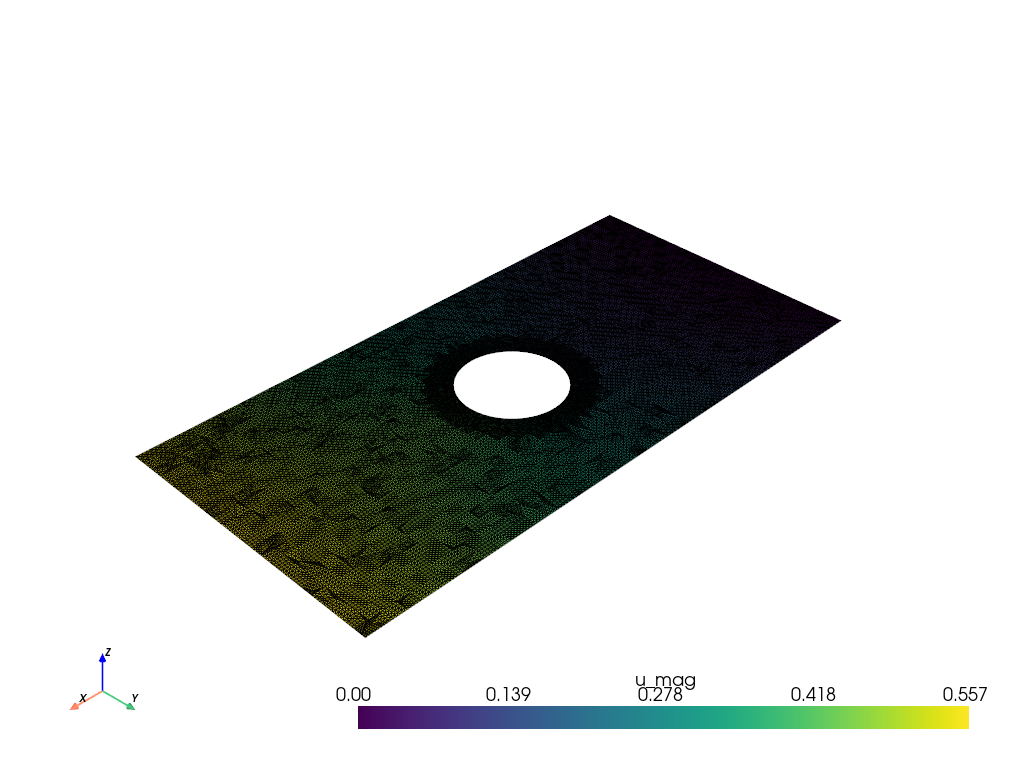

In [9]:
import pyvista as pv
pv.set_jupyter_backend("static")

mesh = pv.read("plate_with_hole_solution.vtk")
mesh.plot(scalars="u_mag", cmap="viridis", show_edges=True)


## POD Basis (Offline ROM step)


Number of modes selected: 4
Selected POD modes: 4


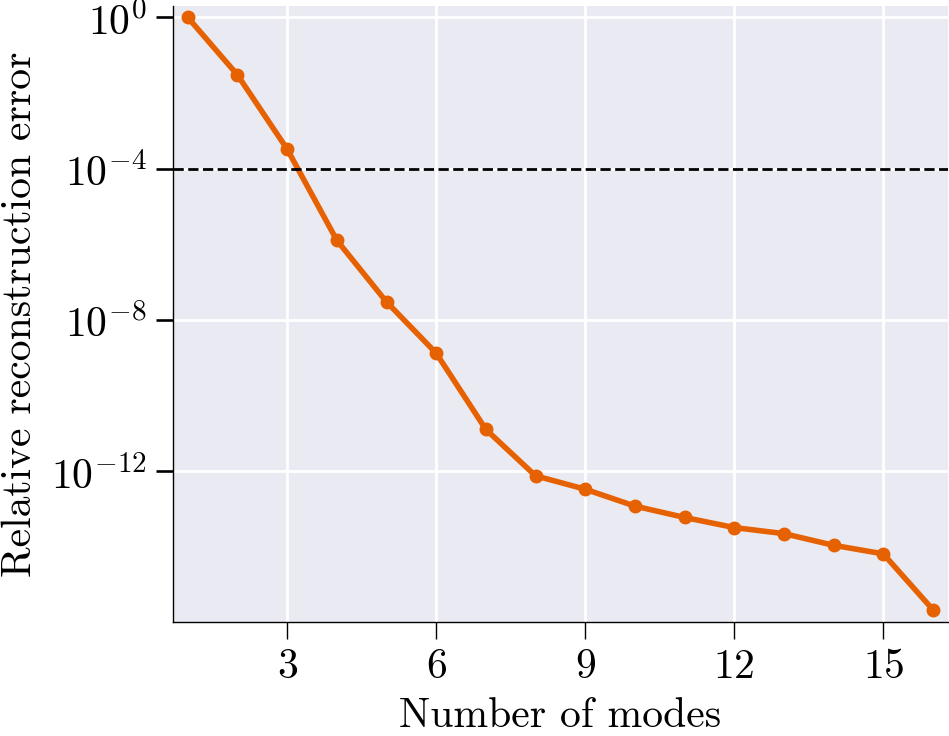

In [10]:
# mean + mean-shifted training matrix
LS_train_mean = np.mean(LS_train, axis=0)
LS_train_ms = LS_train - LS_train_mean

n_sel, U = svd_mode_selector(LS_train_ms, tolerance=1e-4, modes=True)
V_sel = U[:, :n_sel]

print("Selected POD modes:", n_sel)


## ROM Simulation (Online)


In [11]:
rom = master.rom_simulation(V_sel=V_sel, train_ref=LS_train_mean)
rom.run_rom_simulation()

LS_rom = np.asarray(rom.rom_solutions)
ROM_relative_error = rom.rom_error
ROM_speed_up = rom.speed_up

print("Mean ROM relative error (%):", np.mean(ROM_relative_error))
print("Mean ROM speed-up:", np.mean(ROM_speed_up))


[load_rom_data] loaded from d:\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\tests\problem_plate_with_hole_tension_2d\ROM_data
Snap 1/32 params=[6.21770519 0.22057798]
Snap 2/32 params=[5.70456682 0.33761748]
Snap 3/32 params=[3.8554355  0.28697927]
Snap 4/32 params=[8.3480249  0.38838852]
Snap 5/32 params=[9.58355306 0.31328301]
Snap 6/32 params=[2.08798605 0.43239723]
Snap 7/32 params=[4.46932881 0.25469905]
Snap 8/32 params=[7.98339964 0.35818397]
Snap 9/32 params=[7.05682055 0.27526464]
Snap 10/32 params=[4.5524626  0.40793081]
Snap 11/32 params=[2.88985631 0.20104283]
Snap 12/32 params=[9.37561639 0.34932494]
Snap 13/32 params=[8.67315616 0.24296966]
Snap 14/32 params=[3.1863716  0.37771055]
Snap 15/32 params=[5.25423642 0.29376261]
Snap 16/32 params=[6.76147994 0.44412039]
Mean ROM relative error (%): 4.306395539075786e-06
Mean ROM speed-up: 725.8020134485585


## Post-processing: Stress components and von Mises


Test param (E, nu): 6.217705190181732 0.22057797531597317
von Mises max (FOM, ROM): 3.537389868978827 3.5373888032023206


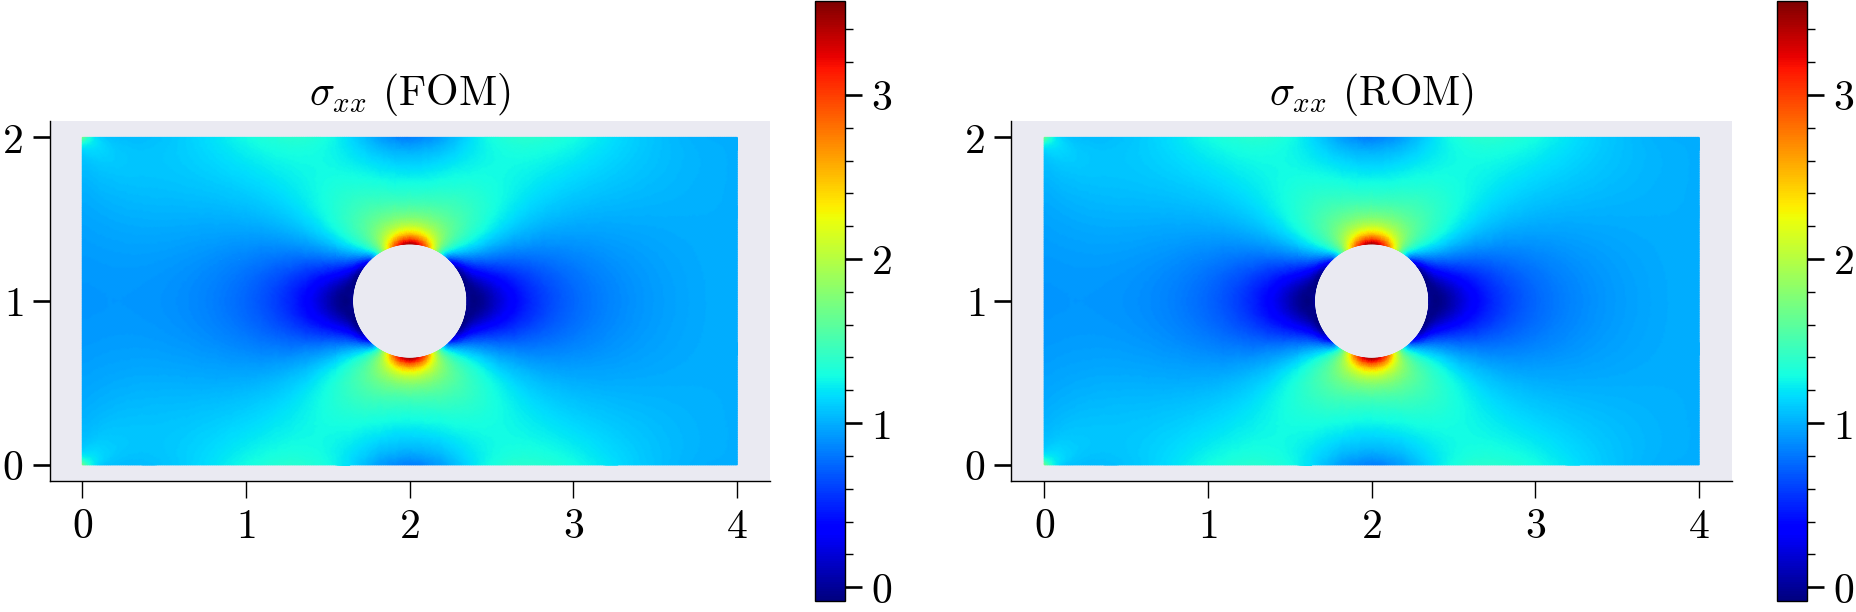

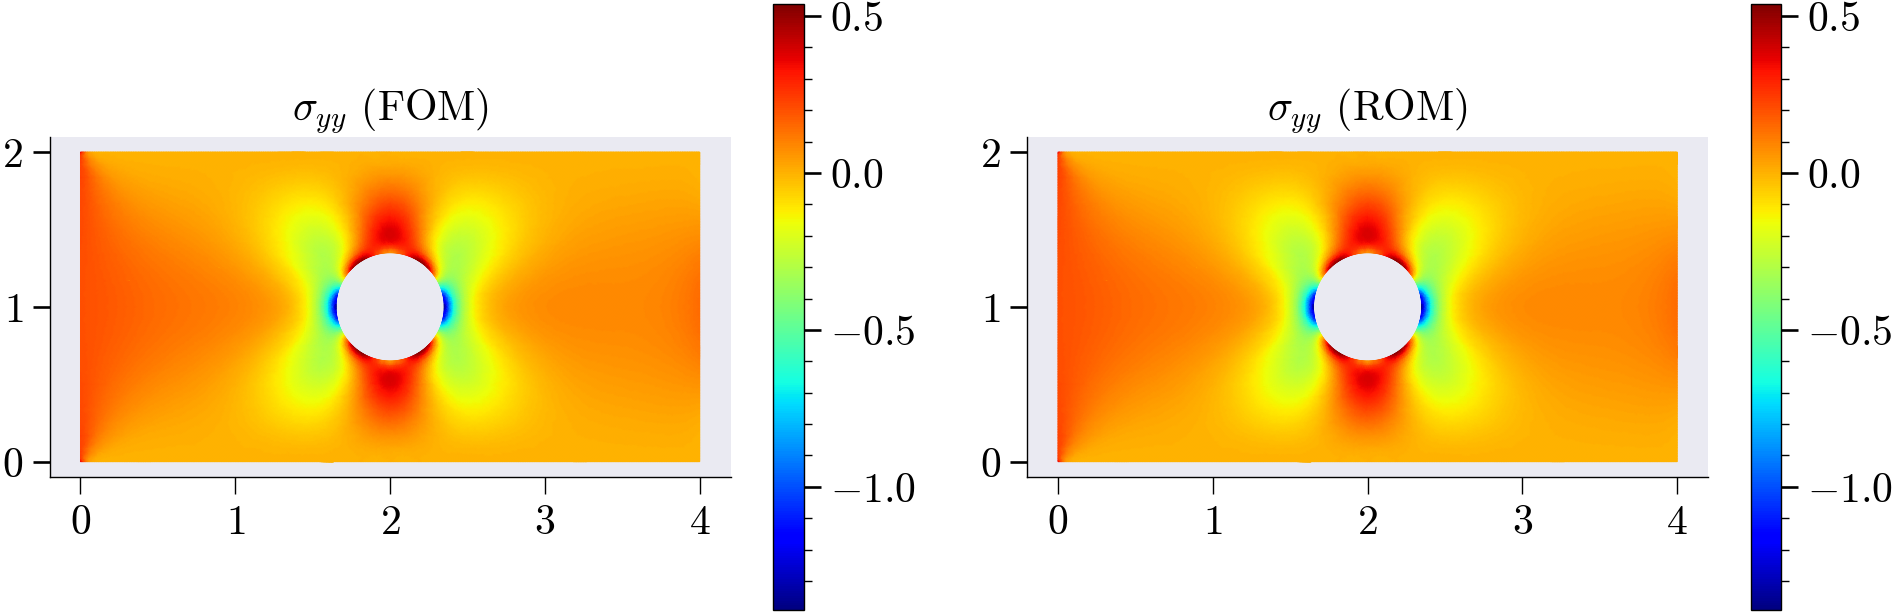

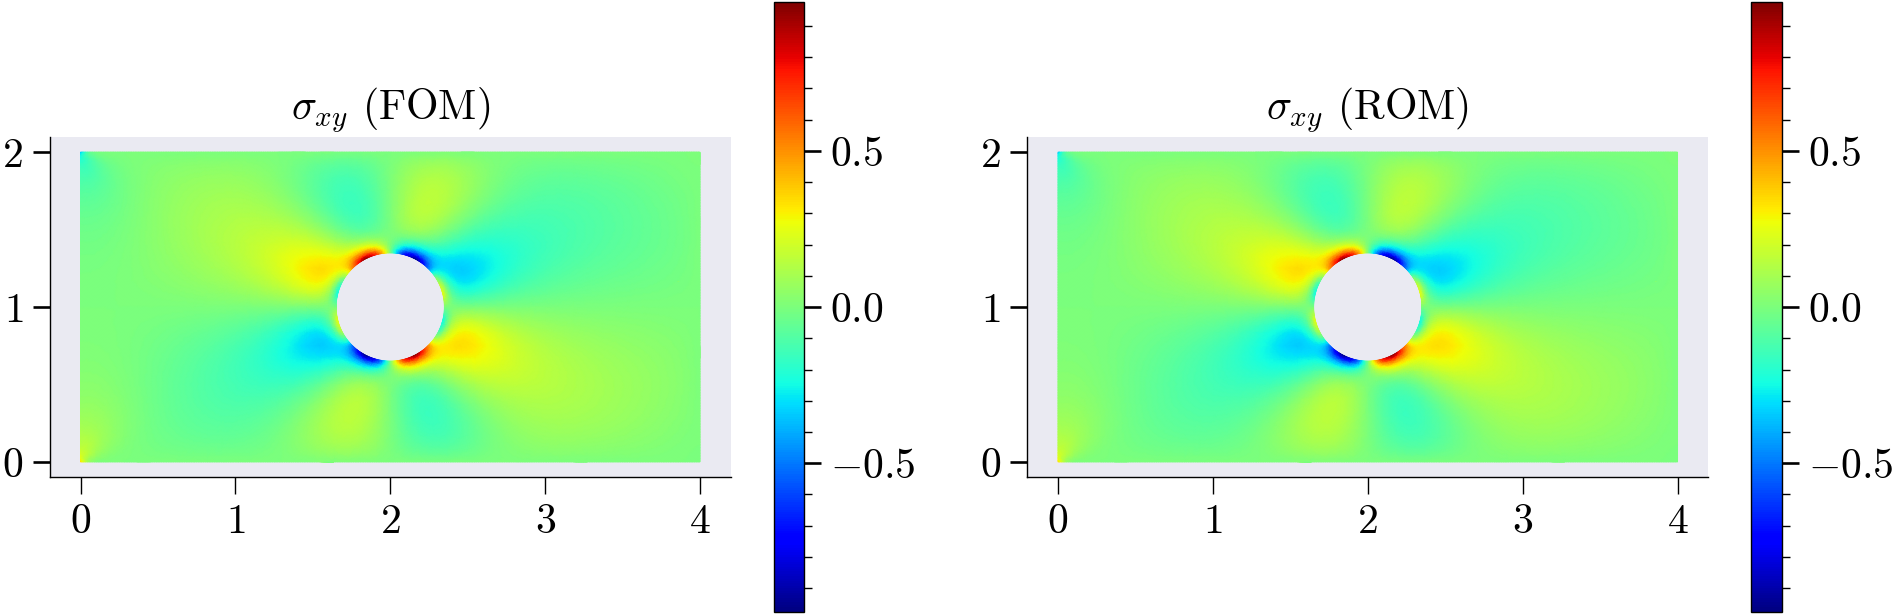

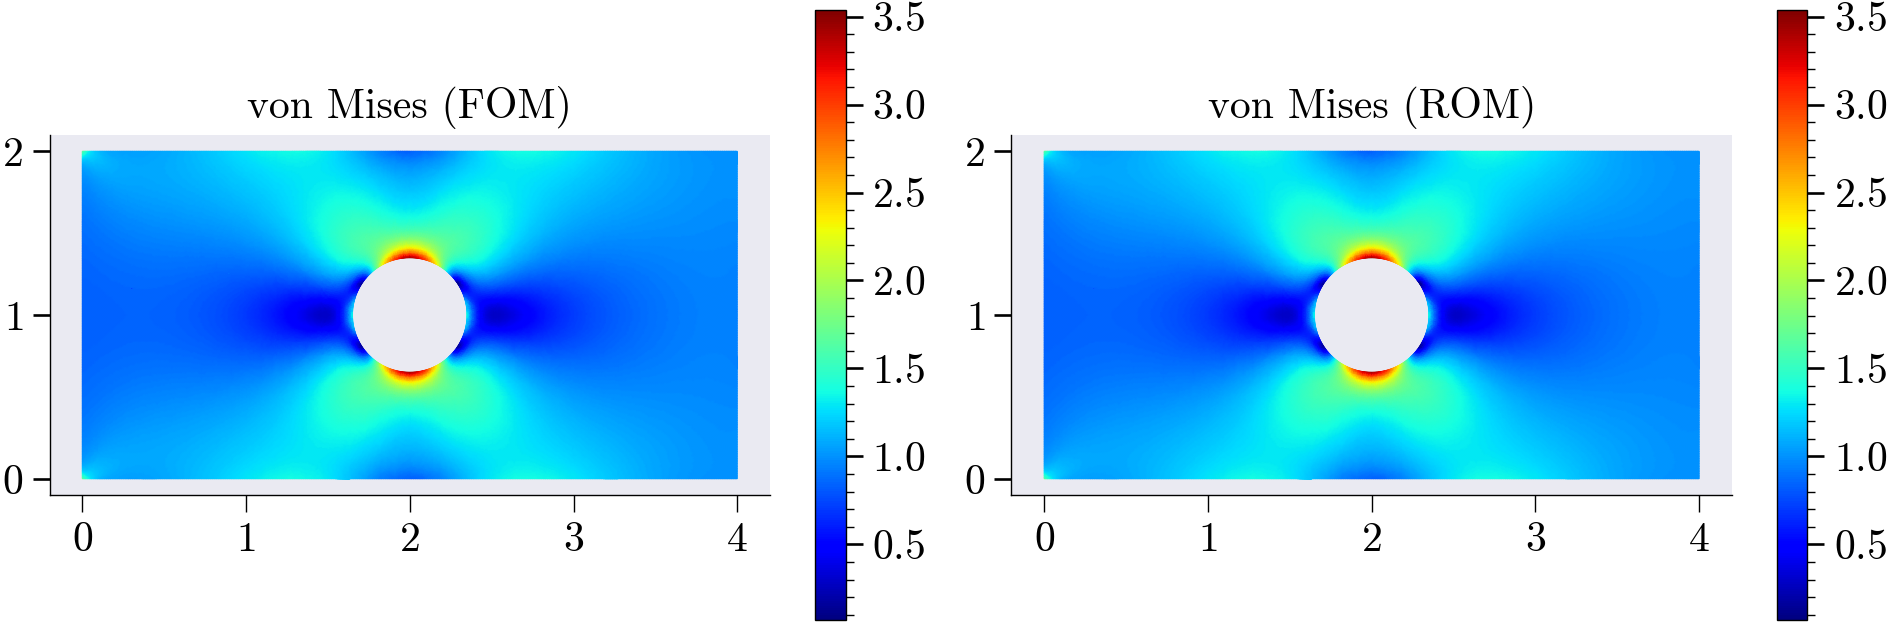

Relative error (von Mises, nodal L2): 9.545108295386332e-08


In [12]:
from skfem import Basis, ElementTriP1
from skfem.visuals.matplotlib import plot

def compute_nodal_stress_plane_stress(mesh, u_full, E, nu):
    """
    Compute nodal stresses for P1 triangle displacement (vector P1).

    Returns nodal arrays:
        sxx, syy, sxy, von_mises
    """
    # node coords and connectivity
    p = mesh.p.T  # (n_nodes, 2)
    t = mesh.t.T  # (n_elems, 3)
    n_nodes = p.shape[0]
    n_elems = t.shape[0]

    # nodal displacement components (assumes u_full contains nodal dofs first)
    # For vector P1 in skfem: basis.nodal_dofs has shape (2, n_nodes)
    basis_vec = sim_data['basis'].item()
    u_node = u_full[basis_vec.nodal_dofs]  # (2, n_nodes)
    ux = u_node[0, :]
    uy = u_node[1, :]

    # element node indices
    i1, i2, i3 = t[:, 0], t[:, 1], t[:, 2]

    x1, y1 = p[i1, 0], p[i1, 1]
    x2, y2 = p[i2, 0], p[i2, 1]
    x3, y3 = p[i3, 0], p[i3, 1]

    # triangle area (2A in denominator)
    twoA = (x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1)

    # gradients for P1
    dN1dx = (y2 - y3) / twoA
    dN1dy = (x3 - x2) / twoA
    dN2dx = (y3 - y1) / twoA
    dN2dy = (x1 - x3) / twoA
    dN3dx = (y1 - y2) / twoA
    dN3dy = (x2 - x1) / twoA

    # gather displacements per element
    ux1, uy1 = ux[i1], uy[i1]
    ux2, uy2 = ux[i2], uy[i2]
    ux3, uy3 = ux[i3], uy[i3]

    # strain components (small strain)
    exx = dN1dx * ux1 + dN2dx * ux2 + dN3dx * ux3
    eyy = dN1dy * uy1 + dN2dy * uy2 + dN3dy * uy3
    gxy = (dN1dy * ux1 + dN2dy * ux2 + dN3dy * ux3) + (dN1dx * uy1 + dN2dx * uy2 + dN3dx * uy3)

    # plane stress constitutive
    fac = E / (1.0 - nu**2)
    sxx_e = fac * (exx + nu * eyy)
    syy_e = fac * (nu * exx + eyy)
    sxy_e = (E / (2.0 * (1.0 + nu))) * gxy

    vm_e = np.sqrt(sxx_e**2 - sxx_e*syy_e + syy_e**2 + 3.0*sxy_e**2)

    # nodal averaging
    sxx = np.zeros(n_nodes); syy = np.zeros(n_nodes); sxy = np.zeros(n_nodes); vm = np.zeros(n_nodes)
    cnt = np.zeros(n_nodes)

    for arr_e, arr_n in [(sxx_e, sxx), (syy_e, syy), (sxy_e, sxy), (vm_e, vm)]:
        np.add.at(arr_n, i1, arr_e)
        np.add.at(arr_n, i2, arr_e)
        np.add.at(arr_n, i3, arr_e)

    np.add.at(cnt, i1, 1.0); np.add.at(cnt, i2, 1.0); np.add.at(cnt, i3, 1.0)
    cnt_safe = np.where(cnt > 0.0, cnt, 1.0)
    sxx /= cnt_safe; syy /= cnt_safe; sxy /= cnt_safe; vm /= cnt_safe

    return sxx, syy, sxy, vm


mesh = sim_data['mesh'].item()
scalar_basis = Basis(mesh, ElementTriP1())

# pick a test snapshot to compare
idx = 0
param = param_list[test_mask][idx]
E, nu = float(param[0]), float(param[1])

u_fom = LS_test[idx]
u_rom = LS_rom[idx]

sxx_f, syy_f, sxy_f, vm_f = compute_nodal_stress_plane_stress(mesh, u_fom, E, nu)
sxx_r, syy_r, sxy_r, vm_r = compute_nodal_stress_plane_stress(mesh, u_rom, E, nu)

print("Test param (E, nu):", E, nu)
print("von Mises max (FOM, ROM):", np.max(vm_f), np.max(vm_r))

def plot_pair(title, a, b):
    fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
    plot(scalar_basis, a, ax=axs[0], shading='gouraud', colorbar=True)
    axs[0].set_title(title + " (FOM)")
    plot(scalar_basis, b, ax=axs[1], shading='gouraud', colorbar=True)
    axs[1].set_title(title + " (ROM)")
    for ax in axs: ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

plot_pair(r"$\sigma_{xx}$", sxx_f, sxx_r)
plot_pair(r"$\sigma_{yy}$", syy_f, syy_r)
plot_pair(r"$\sigma_{xy}$", sxy_f, sxy_r)
plot_pair(r"von Mises", vm_f, vm_r)

# stress-field relative error (nodal)
rel_vm = np.linalg.norm(vm_f - vm_r) / np.linalg.norm(vm_f)
print("Relative error (von Mises, nodal L2):", rel_vm)
